In [47]:
import os
import pertpy as pt
import scanpy as sc
import pandas as pd
import mudata as mu
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

milo = pt.tl.Milo()

from pertpy.tools import Milo


In [2]:
adata_age_cd4= sc.read_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd4_combined_annot_with_age_scvi.h5ad")

In [3]:
adata_age_cd4

AnnData object with n_obs × n_vars = 552283 × 2889
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collect

In [4]:
adata_age_cd4.obs["Age_group"].value_counts().sort_index()

Age_group
0–3      141666
4–6      123469
7–10      84101
11–14    151034
15–18     52013
Name: count, dtype: int64

In [5]:
adata_age_cd4.obs['cell_type'].unique()
adata_age_cd4.obs['cell_type'].value_counts()

cell_type
Naive/Central memory CD4 T cell    352568
CCR4+ CCR6+ memory CD4 T cell       32809
TOX+ CD4 T cell                     25003
Tfh                                 22711
Tfh cell                            21688
Th2 cell                            18195
Th2-like T cell                     17054
TIGIT+ TOX+ memory CD4 T cell       16203
CCR6+ memory CD4 T cell             15731
CCR6+ CD4 T cell                     7431
CTLA4+ TOX+ CD4 T cell               7049
CCR4+ CD4 T cell                     5546
Treg                                 2566
Cytotoxic CD4 T cell                 2436
Th2                                  2333
CCR4+ memory CD4 T cell              2186
Unknown CD4 T cell                    559
Innate-like CD4 T cell                165
Regulatory T cell                      50
Name: count, dtype: int64

In [6]:
adata_age_cd4.obs["pica_id"].unique()
adata_age_cd4.obs["pica_id"].value_counts()

pica_id
PICA0010    7670
PICA0008    7658
PICA0024    7424
PICA0119    7264
PICA0089    7227
            ... 
PICA0006    1512
PICA0004    1172
PICA0003    1134
PICA0002     984
PICA0005     680
Name: count, Length: 128, dtype: int64

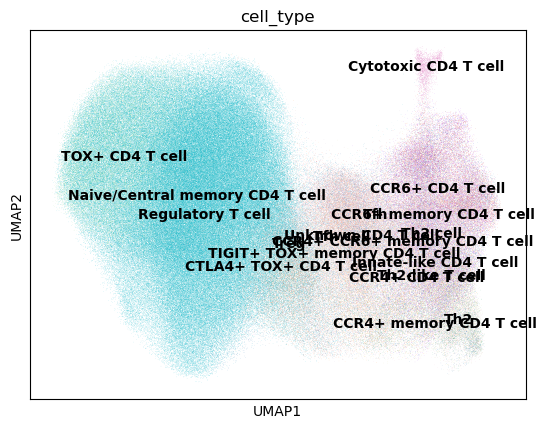

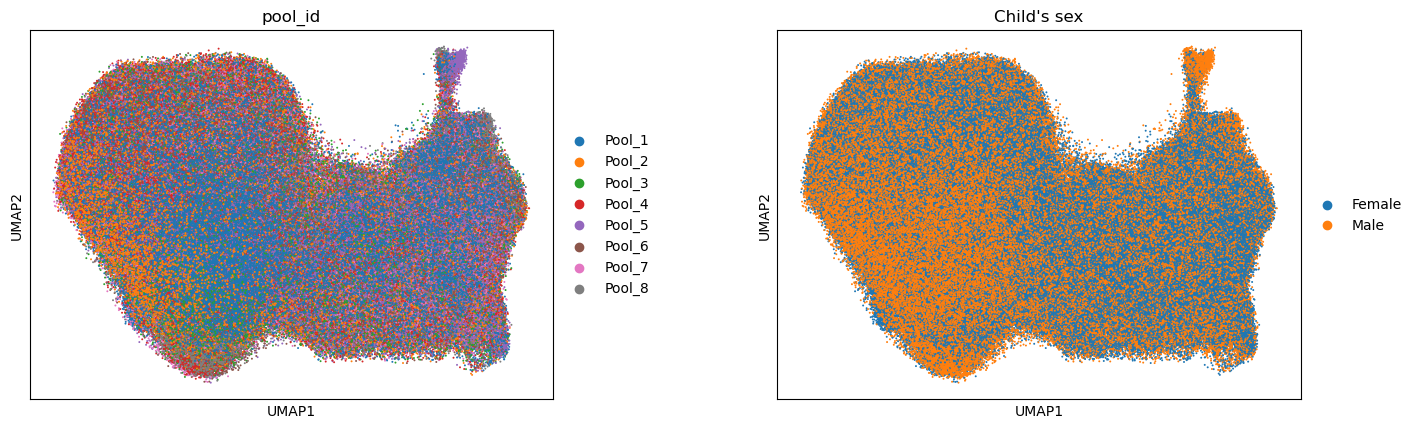

In [7]:
sc.pl.umap(adata_age_cd4, color=["cell_type"], legend_loc="on data")
sc.pl.umap(adata_age_cd4, color=["pool_id", "Child's sex"], wspace=0.3, size=8)

### Prepare for Milo analysis

In [8]:
adata_age_cd4.obs["Age_group"] = pd.Categorical(
        adata_age_cd4.obs["Age_group"],
        categories=["0–3", "4–6", "7–10", "11–14", "15–18"],
        ordered=True,
    )

In [9]:
adata_age_cd4.obs["Child_sex"] = adata_age_cd4.obs["Child's sex"].astype("category")

In [10]:
adata_age_cd4.obs["Child's sex"].value_counts()


Child's sex
Male      294438
Female    257845
Name: count, dtype: int64

In [11]:
adata_age_cd4.obs["Child_sex"].value_counts()

Child_sex
Male      294438
Female    257845
Name: count, dtype: int64

In [12]:
milo = pt.tl.Milo()
mdata_cd4 = milo.load(adata_age_cd4)

In [13]:
mdata_cd4

MuData object with n_obs × n_vars = 552283 × 2889
  2 modalities
    rna:	552283 x 2889
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Age in years int', 'Age_group', '_scvi_batch', '_scvi_labels', 'Child_sex'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'Age_group_colors', "Child's sex_colors", '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'pica_broad_cell_type_complete_01_gdT_corrected_colors', 'pica_id_colors', 'sequencing_batch_colors', 'umap', 'pool_id_colors'
      obsm:	'X_pca', 'X_scVI', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
  

In [14]:
# Build KNN graph
sc.pp.neighbors(mdata_cd4["rna"], use_rep="X_scVI", n_neighbors=150)

In [15]:
# Build neighbourhood graph
milo.make_nhoods(mdata_cd4["rna"], prop=0.1)

In [16]:
mdata_cd4["rna"].obsm["nhoods"]

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 14137515 stored elements and shape (552283, 21356)>

In [17]:
mdata_cd4["rna"][mdata_cd4["rna"].obs["nhood_ixs_refined"] != 0].obs[["nhood_ixs_refined", "nhood_kth_distance"]]

,nhood_ixs_refined,nhood_kth_distance
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACGCTGTGGATTCG,1,3.970337
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACGTAAGCGATTCA,1,3.308883
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACTTATCGTAGCAC,1,3.210726
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAAGGGTTCACGCTAA,1,3.392256
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAAGGTATCGGACGTT,1,3.636754
...,...,...
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GTATGTGTCGTTCGCC,1,3.092845
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GTCATCAAGAGTGCGA,1,3.418285
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GTCATCGCAACGTACT,1,3.692478
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GTGAAATCACTGCTCT,1,3.286907


Text(0, 0.5, '# nhoods')

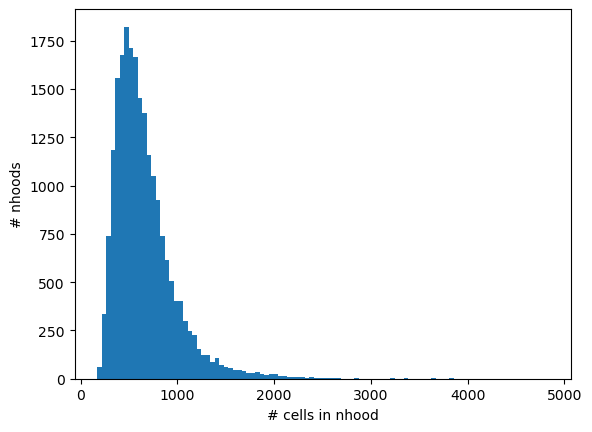

In [18]:
nhood_size = np.array(mdata_cd4["rna"].obsm["nhoods"].sum(0)).ravel()
plt.hist(nhood_size, bins=100)
plt.xlabel("# cells in nhood")
plt.ylabel("# nhoods")

In [19]:
# count cells in neighbourhood
mdata_cd4= milo.count_nhoods(mdata_cd4, sample_col="pica_id") 

In [20]:
mdata_cd4

MuData object with n_obs × n_vars = 552283 × 2889
  2 modalities
    rna:	552283 x 2889
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Age in years int', 'Age_group', '_scvi_batch', '_scvi_labels', 'Child_sex', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'Age_group_colors', "Child's sex_colors", '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'pica_broad_cell_type_complete_01_gdT_corrected_colors', 'pica_id_colors', 'sequencing_batch_colors', 'umap', 'pool_id_colors', 'nhood_neighbors_key'
      obsm:	'X_pca', 'X_scVI', 'X_umap'

In [21]:
mdata_cd4["milo"]

AnnData object with n_obs × n_vars = 128 × 21356
    var: 'index_cell', 'kth_distance'
    uns: 'sample_col'

In [22]:
donor_meta = (
    adata_age_cd4.obs[["pica_id", "Age_group", "Child_sex"]]
    .drop_duplicates("pica_id")
    .set_index("pica_id")
)
donor_meta = donor_meta.loc[mdata_cd4["milo"].obs_names]

In [23]:
mdata_cd4["milo"].obs["Age_group"] = donor_meta["Age_group"].values
mdata_cd4["milo"].obs["Child_sex"] = donor_meta["Child_sex"].values

In [24]:
mdata_cd4["milo"].obs["Age_group"] = pd.Categorical(
    mdata_cd4["milo"].obs["Age_group"],
    categories=["0-3", "4-6", "7-10", "11-14", "15-18"],
    ordered=True
)
mdata_cd4["milo"].obs["Child_sex"] = mdata_cd4["milo"].obs["Child_sex"].astype("category")


### DA testing with GLM

In [25]:
mdata_cd4

MuData object with n_obs × n_vars = 552283 × 2889
  2 modalities
    rna:	552283 x 2889
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Age in years int', 'Age_group', '_scvi_batch', '_scvi_labels', 'Child_sex', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'Age_group_colors', "Child's sex_colors", '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'pica_broad_cell_type_complete_01_gdT_corrected_colors', 'pica_id_colors', 'sequencing_batch_colors', 'umap', 'pool_id_colors', 'nhood_neighbors_key'
      obsm:	'X_pca', 'X_scVI', 'X_umap'

In [26]:
milo.da_nhoods(
    mdata_cd4,
    design="~ Child_sex + Age_group",   # Age_group last = main effect of interest
    solver="pydeseq2"                  # use "edger" only if you set up rpy2+edgeR
)

Fitting size factors...
... done in 0.03 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 5.26 seconds.

Fitting dispersion trend curve...
/home/s4575250/miniforge3/envs/milo/lib/python3.12/site-packages/pydeseq2/dds.py:820: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.24 seconds.

Fitting MAP dispersions...
... done in 5.70 seconds.

Fitting LFCs...
... done in 5.66 seconds.

Calculating cook's distance...
... done in 0.08 seconds.

Replacing 603 outlier genes.

Fitting dispersions...
... done in 0.27 seconds.

Fitting MAP dispersions...
... done in 0.24 seconds.

Fitting LFCs...
... done in 0.31 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: Age_group 15–18 vs 0–3
        baseMean  log2FoldChange     lfcSE      stat        pvalue  \
0       3.778037        5.613564  1.489470  3.768833  1.640126e-04   
1       5.059388        1.679738  0.608332  2.761221  5.758567e-03   
2       5.299030        1.531015  0.633289  2.417563  1.562483e-02   
3       4.191361        2.504810  0.549086  4.561779  5.072194e-06   
4       6.440320        5.629900  1.279286  4.400815  1.078453e-05   
...          ...             ...       ...       ...           ...   
21351  11.349455       -3.928257  0.610601 -6.433428  1.247580e-10   
21352   5.819393       -5.229277  0.952566 -5.489671  4.026823e-08   
21353   3.096665       -0.383196  0.715624 -0.535471  5.923242e-01   
21354   5.161930       -0.831845  0.608029 -1.368102  1.712803e-01   
21355   6.235108        3.735051  1.067413  3.499161  4.667241e-04   

               padj  
0      4.704366e-04  
1      1.143556e-02  
2      2.784194e-02  
3      2.0

... done in 2.18 seconds.



In [27]:
mdata_cd4["milo"].obs

,Child_sex,Age_group,pica_id
PICA0001,Male,0–3,PICA0001
PICA0002,Male,15–18,PICA0002
PICA0003,Male,0–3,PICA0003
PICA0004,Male,0–3,PICA0004
PICA0005,Male,7–10,PICA0005
...,...,...,...
PICA0164,Male,0–3,PICA0164
PICA0166,Male,0–3,PICA0166
PICA0168,Male,15–18,PICA0168
PICA0169,Male,0–3,PICA0169


In [28]:
mdata_cd4["milo"].var

,index_cell,kth_distance,logCPM,logFC,PValue,FDR,SpatialFDR
0,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.970337,3.778037,5.613564,1.640126e-04,4.704366e-04,4.779545e-04
1,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.308883,5.059388,1.679738,5.758567e-03,1.143556e-02,1.151786e-02
2,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.210726,5.299030,1.531015,1.562483e-02,2.784194e-02,2.799397e-02
3,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.392256,4.191361,2.504810,5.072194e-06,2.039214e-05,2.091481e-05
4,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.636754,6.440320,5.629900,1.078453e-05,4.027383e-05,4.122568e-05
...,...,...,...,...,...,...,...
21351,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.092845,11.349455,-3.928257,1.247580e-10,1.248049e-09,1.313044e-09
21352,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.418285,5.819393,-5.229277,4.026823e-08,2.474151e-07,2.572404e-07
21353,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.692478,3.096665,-0.383196,5.923242e-01,6.584882e-01,6.587265e-01
21354,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.286907,5.161930,-0.831845,1.712803e-01,2.288893e-01,2.294153e-01


In [ ]:
mdata_cd4.write_h5mu("/scratch/user/s4575250/BIOX7018_thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd4_combined_annot_with_age_nhood.h5mu")


In [34]:
mdata_cd4["milo"].var.to_csv("/scratch/user/s4575250/BIOX7018_thesis/data/figures/PICA_Batch001-Batch007/03_milo/milo_cd4_age_sex_DA_results.csv")

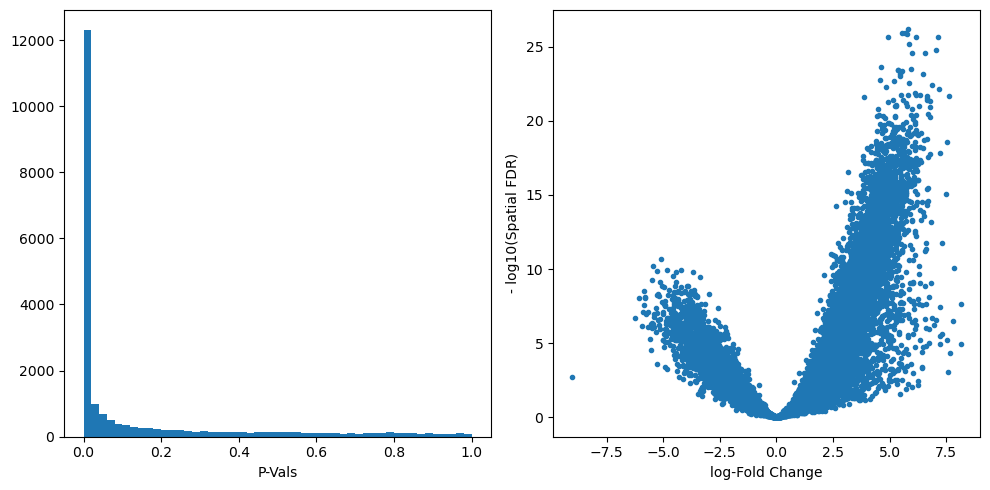

In [37]:
# QC
old_figsize = plt.rcParams["figure.figsize"]
plt.rcParams["figure.figsize"] = [10, 5]
plt.subplot(1, 2, 1)
plt.hist(mdata_cd4["milo"].var.PValue, bins=50)
plt.xlabel("P-Vals")
plt.subplot(1, 2, 2)
plt.plot(mdata_cd4["milo"].var.logFC, -np.log10(mdata_cd4["milo"].var.SpatialFDR), ".")
plt.xlabel("log-Fold Change")
plt.ylabel("- log10(Spatial FDR)")
plt.tight_layout()
plt.rcParams["figure.figsize"] = old_figsize

### Visualize embedding

In [38]:
milo.build_nhood_graph(mdata_cd4)

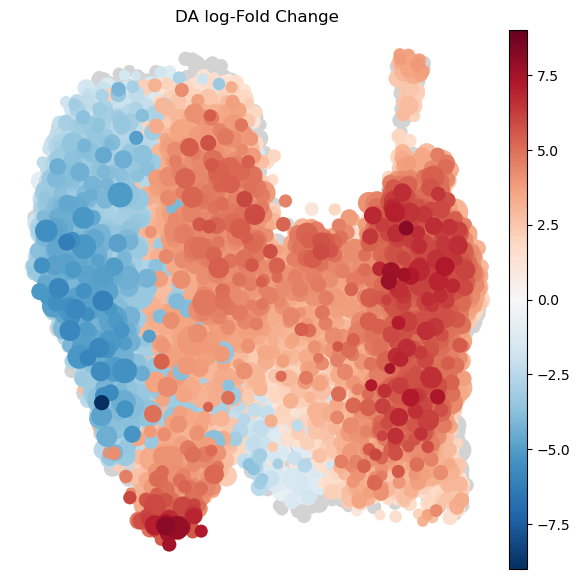

In [39]:
plt.rcParams["figure.figsize"] = [7, 7]
milo.plot_nhood_graph(
    mdata_cd4,
    alpha=0.1,  # SpatialFDR level (1%)
    min_size=1,  # Size of smallest dot
)

### Visualize by cell type

In [40]:
milo.annotate_nhoods(mdata_cd4, anno_col="cell_type")


Text(0.5, 0, 'celltype fraction')

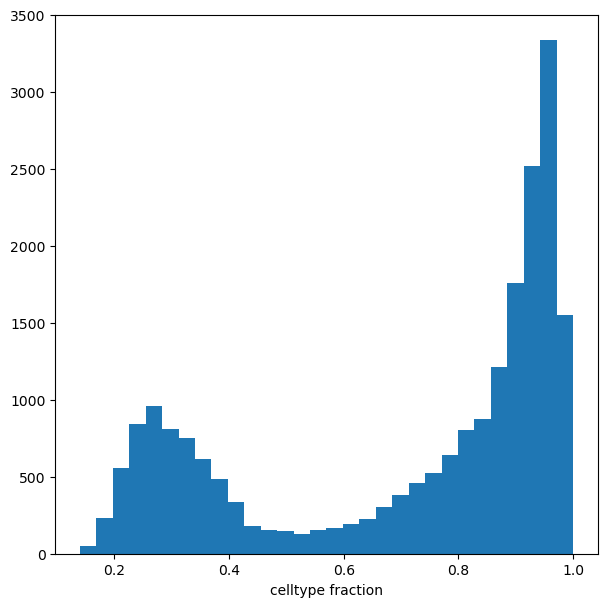

In [41]:
plt.hist(mdata_cd4["milo"].var["nhood_annotation_frac"], bins=30)
plt.xlabel("celltype fraction")

In [42]:
mdata_cd4["milo"].var["nhood_annotation"] = mdata_cd4["milo"].var["nhood_annotation"].cat.add_categories("Mixed")
mdata_cd4["milo"].var.loc[mdata_cd4["milo"].var["nhood_annotation_frac"] < 0.6, "nhood_annotation"] = "Mixed"

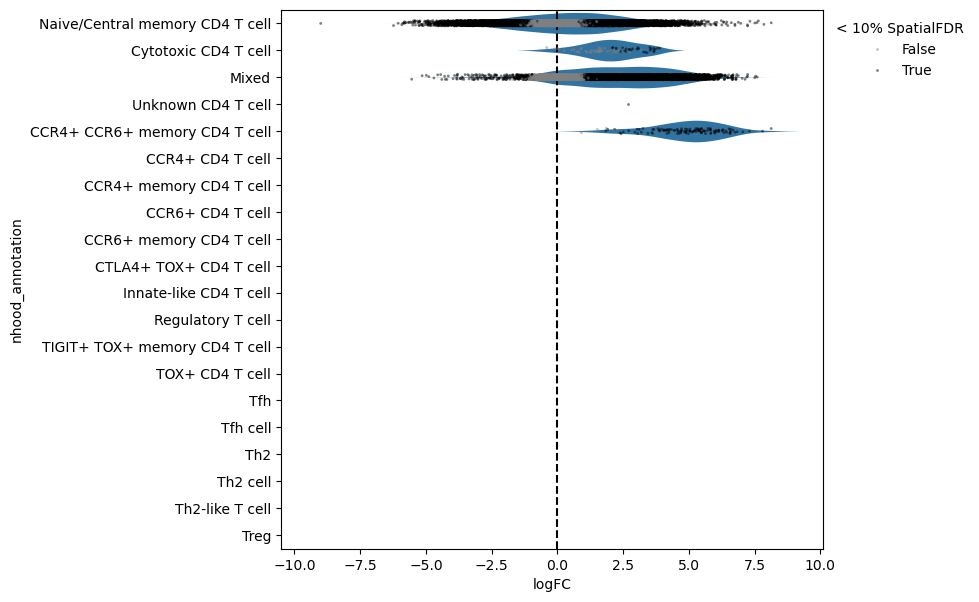

In [43]:
milo.plot_da_beeswarm(mdata_cd4, alpha=0.1)

In [44]:
sig_nhoods = mdata_cd4["milo"].var.query(
    "SpatialFDR < 0.1"
).copy()

sig_nhoods.sort_values("logFC", ascending=False).head()

,index_cell,kth_distance,logCPM,logFC,PValue,FDR,SpatialFDR,Nhood_size,nhood_annotation,nhood_annotation_frac
71,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.528494,12.054550,8.129364,2.767582e-06,1.176140e-05,1.208698e-05,752.0,Naive/Central memory CD4 T cell,0.929521
1600,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,4.342715,10.169942,8.128945,2.899502e-09,2.212844e-08,2.318103e-08,456.0,CCR4+ CCR6+ memory CD4 T cell,0.831140
3048,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.515392,23.860796,7.850696,6.389141e-12,8.235924e-11,8.694402e-11,1151.0,Naive/Central memory CD4 T cell,0.967854
1377,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,4.155974,11.926955,7.799512,5.411582e-08,3.238135e-07,3.365741e-07,545.0,CCR4+ CCR6+ memory CD4 T cell,0.899083
3081,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.921621,6.780773,7.641122,1.274779e-05,4.699478e-05,4.809262e-05,358.0,Naive/Central memory CD4 T cell,0.910615


<Figure size 700x700 with 0 Axes>

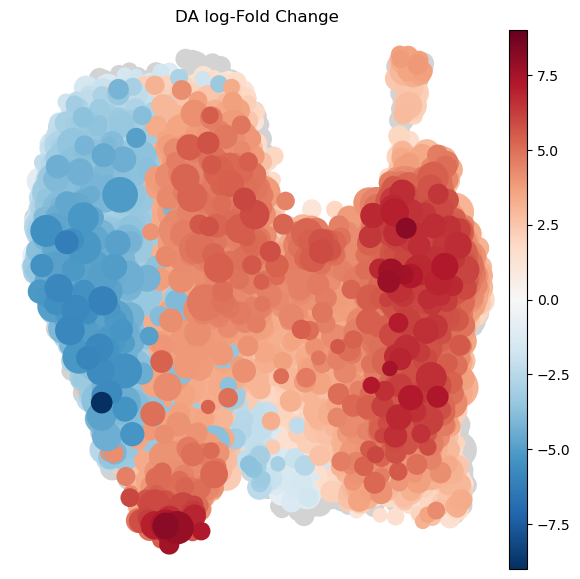

In [45]:
milo.build_nhood_graph(mdata_cd4)

plt.figure(figsize=(7, 7))
milo.plot_nhood_graph(
    mdata_cd4,
    alpha=0.1,        # SpatialFDR threshold
    min_size=2
)

<Axes: xlabel='logFC', ylabel='kth_distance'>

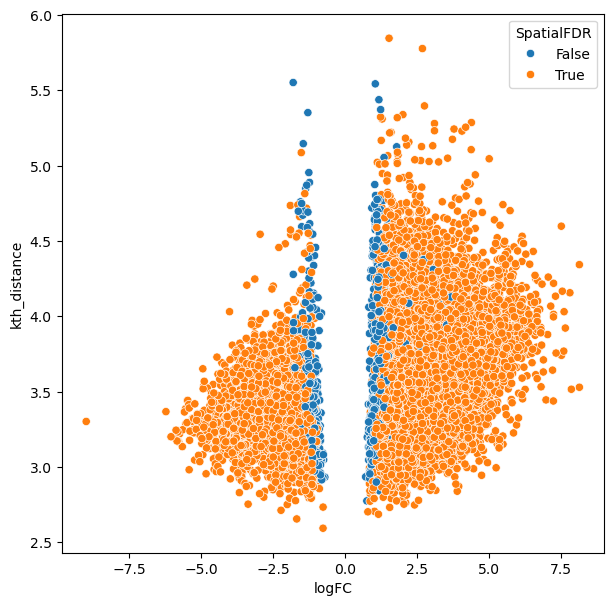

In [48]:
sns.scatterplot(
    data=sig_nhoods,
    x="logFC",
    y="kth_distance",
    hue=(sig_nhoods["SpatialFDR"] < 0.05)
)

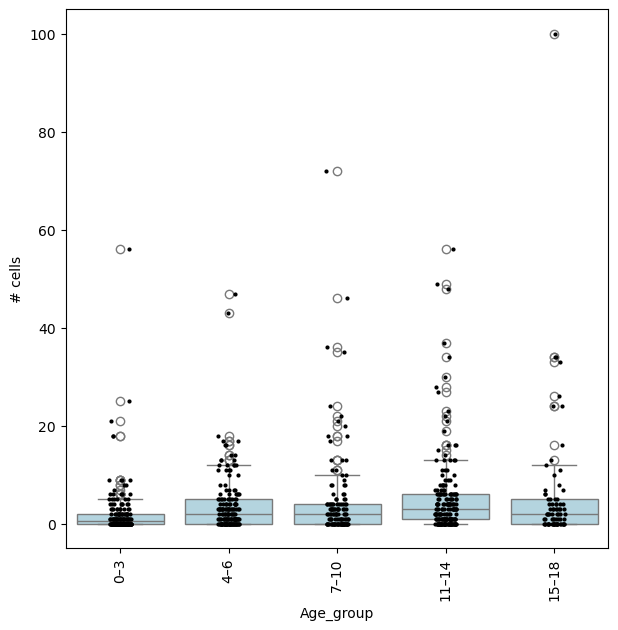

In [50]:
milo.plot_nhood_counts_by_cond(
    mdata_cd4,
    test_var="Age_group",
    subset_nhoods=sig_nhoods.index[:6],
    log_counts=False
)

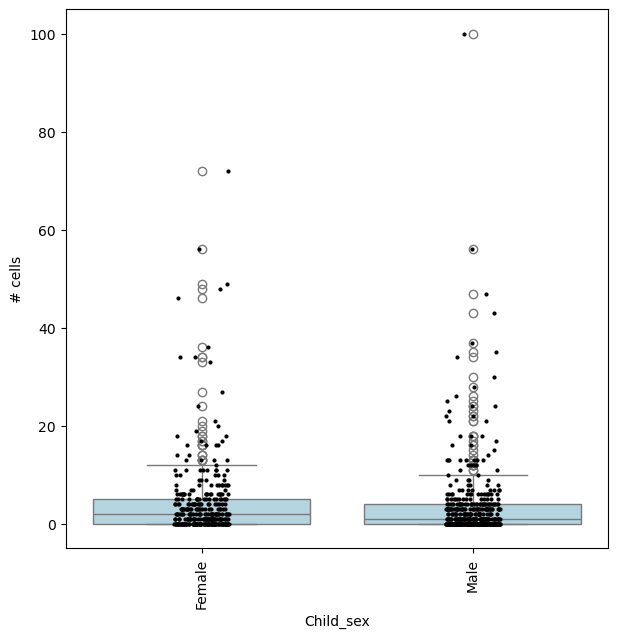

In [51]:
milo.plot_nhood_counts_by_cond(
    mdata_cd4,
    test_var="Child_sex",
    subset_nhoods=sig_nhoods.index[:6],
    log_counts=False
)

In [49]:
## Visualize cell counts by condition (x-axis) and individuals on all neighbourhoods
milo.plot_nhood_counts_by_cond(mdata_cd4, test_var="Child_sex", subset_nhoods=pl_nhoods, log_counts=False)

NameError: name 'pl_nhoods' is not defined